# Phase 2: Win Probability Model

## Learning Objectives
1. Build a **classification model** to predict wins and top-5 finishes
2. Build a **regression model** to predict finish position
3. Understand **machine learning evaluation metrics**
4. Learn **feature importance** - what makes a winner?
5. Combine predictions with prize money for **Expected Value**

## Why This Matters for Your Top-Heavy Strategy
- You need to identify golfers with **high win probability**
- Traditional models predict average finish - we want **ceiling outcomes**
- Understanding variance/volatility helps find boom-or-bust players
- This model feeds into your weekly picks and season-long optimizer

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## Step 1: Load and Prepare Data

**Machine Learning Concept: Train/Test Split**

We need to:
1. Load the data
2. Select relevant features (predictors)
3. Create target variables (what we're predicting)
4. Split into **training** and **test** sets

**Why split?** 
- **Training set**: Teach the model patterns
- **Test set**: Evaluate how well it works on unseen data
- This prevents **overfitting** (memorizing vs. learning)

In [17]:
# Load your data
df = pd.read_csv('full_df.csv')

print(f"Loaded {len(df):,} tournament-player records")
print(f"Players: {df['player_name'].nunique()}")
print(f"Tournaments: {df['tournament_name'].nunique()}")
print(f"\nFirst few rows:")
df[['player_name', 'tournament_name', 'finish_position_num', 'strokes_gained_total_avg', 'earnings']].head(10)

Loaded 3,023 tournament-player records
Players: 368
Tournaments: 44

First few rows:


,player_name,tournament_name,finish_position_num,strokes_gained_total_avg,earnings
0,Phil Mickelson,The Open Championship,56.0,NaN,42333.00
1,Justin Leonard,The Open Championship,59.0,NaN,41550.00
2,Charley Hoffman,The American Express,5.0,0.820,339900.00
3,Charley Hoffman,Farmers Insurance Open,25.0,1.398,74067.86
4,Charley Hoffman,Sony Open in Hawaii,59.0,-0.075,19314.00
5,Charley Hoffman,Cognizant Classic in The Palm Beaches,25.0,1.129,73271.43
6,Charley Hoffman,THE PLAYERS Championship,54.0,-0.097,58250.00
7,Charley Hoffman,Texas Children's Houston Open,64.0,-0.815,20425.00
8,Charley Hoffman,RBC Canadian Open,67.0,-1.253,20874.00
9,Charley Hoffman,Corales Puntacana Championship,9.0,NaN,109000.00


## Step 2: Feature Selection

**Data Science Concept: Feature Engineering**

Not all 143 columns are useful for prediction. We want:
- **Recent form** (rolling averages)
- **Core skills** (SG: Total, components)
- **Volatility** (variance = boom/bust potential)
- **Field strength** (easier fields = better odds for favorites)

We'll focus on **rolling averages** (last 3-5 tournaments) because recent form matters most in golf.

In [18]:
# Define our feature set
# These are the predictors we'll use
features = [
    # Recent form (3-tournament rolling average)
    'strokes_gained_total_avg_tz_roll3',
    'strokes_gained_tee_to_green_avg_tz_roll3',
    'strokes_gained_putting_avg_tz_roll3',
    'strokes_gained_off_the_tee_avg_tz_roll3',
    'strokes_gained_approach_the_green_avg_tz_roll3',
    'strokes_gained_around_the_green_avg_tz_roll3',
    
    # Volatility (how consistent/variable is the player?)
    'strokes_gained_total_avg_tz_vol3',
    'strokes_gained_putting_avg_tz_vol3',
    
    # Longer-term form (5-tournament average)
    'strokes_gained_total_avg_tz_roll5',
    
    # Tournament context
    'field_strength',
    
    # Player history
    'birdie_to_bogey_ratio_value_tz_roll3',
    'cut_rate_r5'  # Recent cut rate (risk factor)
]

print(f"Selected {len(features)} features for modeling")
print("\nFeature list:")
for i, feat in enumerate(features, 1):
    print(f"{i:2d}. {feat}")

Selected 12 features for modeling

Feature list:
 1. strokes_gained_total_avg_tz_roll3
 2. strokes_gained_tee_to_green_avg_tz_roll3
 3. strokes_gained_putting_avg_tz_roll3
 4. strokes_gained_off_the_tee_avg_tz_roll3
 5. strokes_gained_approach_the_green_avg_tz_roll3
 6. strokes_gained_around_the_green_avg_tz_roll3
 7. strokes_gained_total_avg_tz_vol3
 8. strokes_gained_putting_avg_tz_vol3
 9. strokes_gained_total_avg_tz_roll5
10. field_strength
11. birdie_to_bogey_ratio_value_tz_roll3
12. cut_rate_r5


## Step 3: Create Target Variables

**Machine Learning Concept: Classification vs. Regression**

We'll build TWO types of models:

### Classification (Categorical outcomes)
- **Won tournament?** (Yes/No) - Binary classification
- **Top-5 finish?** (Yes/No)
- **Top-10 finish?** (Yes/No)

### Regression (Numeric outcomes)
- **Finish position** (1, 2, 3, ... 70) - Continuous number

For your **top-heavy strategy**, we care most about **win probability**!

In [19]:
# YOUR TASK: Create binary target variables
# Create a column 'won' that is True if finish_position_num == 1, False otherwise
# Create a column 'top5' that is True if finish_position_num <= 5, False otherwise
# Create a column 'top10' that is True if finish_position_num <= 10, False otherwise

# HINT: Use comparison operators (==, <=)
# HINT: Example: df['won'] = df['finish_position_num'] == 1

# YOUR CODE HERE:
df['won'] = df['finish_position_num'] == 1  # Replace with your code
df['top5'] = df['finish_position_num'] <= 5  # Replace with your code
df['top10'] = df['finish_position_num'] <= 10  # Replace with your code

# Verify it worked
print("Target variable distributions:")
print(f"\nWins: {df['won'].sum()} out of {len(df)} ({df['won'].sum()/len(df)*100:.2f}%)")
print(f"Top-5: {df['top5'].sum()} out of {len(df)} ({df['top5'].sum()/len(df)*100:.2f}%)")
print(f"Top-10: {df['top10'].sum()} out of {len(df)} ({df['top10'].sum()/len(df)*100:.2f}%)")

# Show some examples
print("\nSample winners:")
print(df[df['won'] == True][['player_name', 'tournament_name', 'finish_position_num', 'earnings']].head(10))


print("\nSample top 5:")
print(df[df['top5'] == True][['player_name', 'tournament_name' ,'finish_position_num', 'earnings']])

Target variable distributions:

Wins: 44 out of 3023 (1.46%)
Top-5: 273 out of 3023 (9.03%)
Top-10: 500 out of 3023 (16.54%)

Sample winners:
          player_name                 tournament_name  finish_position_num  \
26        Justin Rose     FedEx St. Jude Championship                  1.0   
98        Nick Taylor             Sony Open in Hawaii                  1.0   
211      Brian Harman               Valero Texas Open                  1.0   
258      Rory McIlroy        AT&T Pebble Beach Pro-Am                  1.0   
261      Rory McIlroy        THE PLAYERS Championship                  1.0   
262      Rory McIlroy              Masters Tournament                  1.0   
359          Ryan Fox               RBC Canadian Open                  1.0   
365          Ryan Fox  ONEflight Myrtle Beach Classic                  1.0   
398   Tommy Fleetwood               TOUR Championship                  1.0   
529  Hideki Matsuyama                      The Sentry                  1.0   


## Step 4: Handle Missing Data

**Data Science Concept: Missing Data Strategies**

Some players don't have rolling averages (new to tour, or not enough recent tournaments).

Options:
1. **Drop rows** with missing data (simple but loses info)
2. **Impute** (fill in) with mean/median (assumes average performance)
3. **Use flags** indicating missing data (model can learn this pattern)

For now, we'll drop rows with missing key features to keep it simple.

In [20]:
# Check missing data
print("Missing data in key features:")
for feat in features:
    missing = df[feat].isna().sum()
    pct = (missing / len(df)) * 100
    print(f"{feat:50s}: {missing:4d} ({pct:5.1f}%)")

# Create clean dataset
df_clean = df.dropna(subset=features).copy()

print(f"\nOriginal dataset: {len(df):,} records")
print(f"After removing missing data: {len(df_clean):,} records")
print(f"Kept {len(df_clean)/len(df)*100:.1f}% of data")

Missing data in key features:
strokes_gained_total_avg_tz_roll3                 :   83 (  2.7%)
strokes_gained_tee_to_green_avg_tz_roll3          :   83 (  2.7%)
strokes_gained_putting_avg_tz_roll3               :   83 (  2.7%)
strokes_gained_off_the_tee_avg_tz_roll3           :   83 (  2.7%)
strokes_gained_approach_the_green_avg_tz_roll3    :   83 (  2.7%)
strokes_gained_around_the_green_avg_tz_roll3      :   83 (  2.7%)
strokes_gained_total_avg_tz_vol3                  :  572 ( 18.9%)
strokes_gained_putting_avg_tz_vol3                :  572 ( 18.9%)
strokes_gained_total_avg_tz_roll5                 :   72 (  2.4%)
field_strength                                    :  494 ( 16.3%)
birdie_to_bogey_ratio_value_tz_roll3              :    1 (  0.0%)
cut_rate_r5                                       :  618 ( 20.4%)

Original dataset: 3,023 records
After removing missing data: 1,960 records
Kept 64.8% of data


## Step 5: Train/Test Split

**Machine Learning Concept: Evaluation Strategy**

We'll split our data:
- **80% training**: Model learns from these tournaments
- **20% test**: Model evaluated on these (simulates future predictions)

**Important**: Use `random_state` for reproducibility (same split every time)

In [21]:
# YOUR TASK: Split the data
# Use train_test_split from sklearn

# HINT: X = features (predictor variables)
# HINT: y = target (what we're predicting)
# HINT: test_size=0.2 means 20% test, 80% train

# Prepare X (features) and y (targets)



X = df_clean[features]
y_won = df_clean['won']
y_top5 = df_clean['top5']
y_position = df_clean['finish_position_num']

X_train, X_test, y_train_won, y_test_won = train_test_split(
    X, y_won, 
    test_size=0.2,
    random_state=42
)

print("Data split complete!")
print(f"\nTraining set: {len(X_train):,} records")
print(f"Test set: {len(X_test):,} records")
print(f"\nWins in training: {y_train_won.sum()}")
print(f"Wins in test: {y_test_won.sum()}")

Data split complete!

Training set: 1,568 records
Test set: 392 records

Wins in training: 23
Wins in test: 8


## Step 6: Build Your First Model - Win Prediction

**Machine Learning Algorithm: Random Forest Classifier**

Random Forest is a great starting point because:
- **Handles non-linear relationships** (golf isn't linear!)
- **Shows feature importance** (what matters most?)
- **Robust to outliers**
- **Gives probability estimates** (perfect for Expected Value!)

**How it works:**
1. Creates many "decision trees" (like flowcharts)
2. Each tree votes on the outcome
3. Majority vote = prediction
4. Vote percentage = probability

In [22]:
# Build the model
print("Training Random Forest model for WIN prediction...\n")

# Create the model
rf_win = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=10,      # Max tree depth (prevents overfitting)
    min_samples_leaf=10,  # Minimum samples in leaf nodes
    random_state=42
)

# Train the model
rf_win.fit(X_train, y_train_won)

print("✅ Model trained successfully!")

# Make predictions on test set
y_pred_won = rf_win.predict(X_test)
y_pred_won_proba = rf_win.predict_proba(X_test)[:, 1]  # Probability of winning

print(f"\nPredictions generated for {len(X_test)} test tournaments")







Training Random Forest model for WIN prediction...

✅ Model trained successfully!

Predictions generated for 392 test tournaments


## Step 7: Evaluate Model Performance

**Machine Learning Concept: Classification Metrics**

Key metrics for imbalanced classification (wins are rare!):

- **Accuracy**: Overall % correct (misleading when wins are rare!)
- **Precision**: Of predicted wins, how many were correct?
- **Recall**: Of actual wins, how many did we predict?
- **ROC-AUC**: Overall ability to rank winners higher (0.5 = random, 1.0 = perfect)

For fantasy golf, **Recall** matters - we want to identify as many winners as possible!

In [23]:
# Evaluate the model
from sklearn.metrics import confusion_matrix

print("=== WIN PREDICTION MODEL PERFORMANCE ===\n")

# Classification report
print(classification_report(y_test_won, y_pred_won, target_names=['No Win', 'Win']))

# ROC-AUC score
auc = roc_auc_score(y_test_won, y_pred_won_proba)
print(f"\nROC-AUC Score: {auc:.3f}")
print("(0.5 = random guessing, 1.0 = perfect)\n")

# Confusion matrix
cm = confusion_matrix(y_test_won, y_pred_won)
print("Confusion Matrix:")
print(f"               Predicted: No Win  |  Predicted: Win")
print(f"Actual: No Win      {cm[0,0]:6d}        |      {cm[0,1]:6d}")
print(f"Actual: Win         {cm[1,0]:6d}        |      {cm[1,1]:6d}")

=== WIN PREDICTION MODEL PERFORMANCE ===

              precision    recall  f1-score   support

      No Win       0.98      1.00      0.99       384
         Win       0.00      0.00      0.00         8

    accuracy                           0.98       392
   macro avg       0.49      0.50      0.49       392
weighted avg       0.96      0.98      0.97       392


ROC-AUC Score: 0.980
(0.5 = random guessing, 1.0 = perfect)

Confusion Matrix:
               Predicted: No Win  |  Predicted: Win
Actual: No Win         384        |           0
Actual: Win              8        |           0


## Step 8: Feature Importance

**Data Science Gold: What Makes a Winner?**

Random Forests tell us which features matter most for predicting wins.
This is SUPER valuable for understanding golf strategy!

=== FEATURE IMPORTANCE FOR WINNING ===

                                       feature  importance
              strokes_gained_total_avg_tz_vol3    0.231779
             strokes_gained_total_avg_tz_roll5    0.159828
      strokes_gained_tee_to_green_avg_tz_roll3    0.128422
             strokes_gained_total_avg_tz_roll3    0.117093
          birdie_to_bogey_ratio_value_tz_roll3    0.099356
strokes_gained_approach_the_green_avg_tz_roll3    0.081971
            strokes_gained_putting_avg_tz_vol3    0.073674
           strokes_gained_putting_avg_tz_roll3    0.033789
       strokes_gained_off_the_tee_avg_tz_roll3    0.031205
                                field_strength    0.025898
  strokes_gained_around_the_green_avg_tz_roll3    0.016986
                                   cut_rate_r5    0.000000


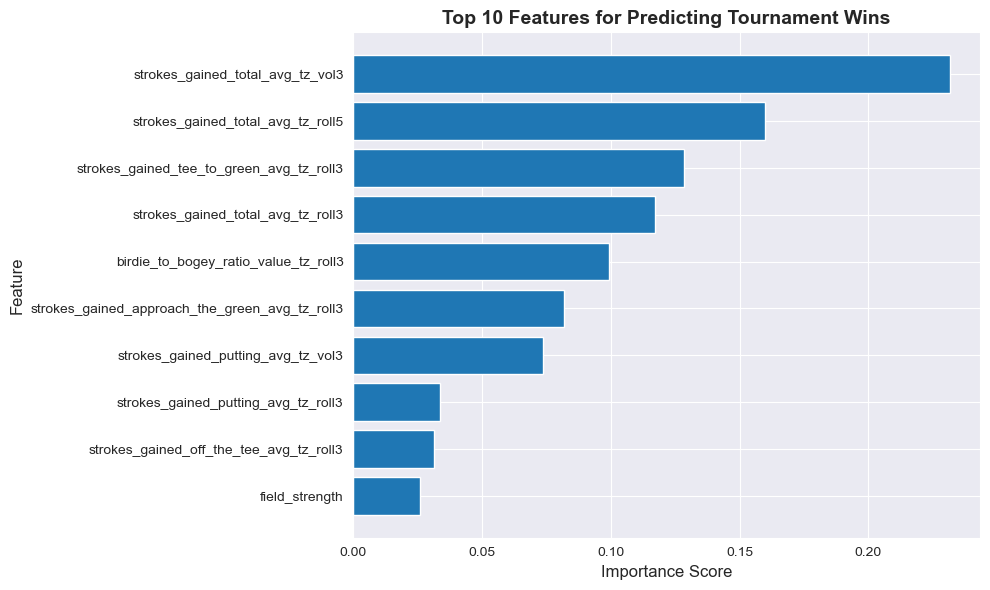


💡 Insight: Which stat matters most for winning? Write your observation:
These features have relatively low importance for being the top ones.


In [24]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_win.feature_importances_
}).sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE FOR WINNING ===\n")
print(feature_importance.to_string(index=False))

# YOUR TASK: Visualize feature importance
# Create a horizontal bar chart showing the top 10 features

# HINT: Use plt.barh() for horizontal bars
# HINT: Sort by importance (already done above)
# HINT: Take top 10 with .head(10)

plt.figure(figsize=(10, 6))


top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Features for Predicting Tournament Wins', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()


print("\n💡 Insight: Which stat matters most for winning? Write your observation:")
print("These features have relatively low importance for being the top ones.")

## Step 9: Analyze Win Probabilities

**The Money Shot: Who Has the Best Chance to Win?**

Let's look at predicted win probabilities and see if they make sense.

In [27]:

# Add prediction back to test data
test_results = df_clean.loc[X_test.index].copy()
test_results['win_probability'] = y_pred_won_proba
test_results['predicted_win'] = y_pred_won

#Show highest win probabilities
print("=== TOP 20 PREDICTED WIN ===\n")
top_predictions = test_results.nlargest(20, "win_probability")
print(top_predictions[[
    'player_name',
    'tournament_name', 
    'win_probability', 
    'finish_position_num',
    'won',
    'strokes_gained_total_avg_tz_roll3'
]].to_string(index=False))

# Check calibration: do high probalities actually win?
test_results['prob_bucket'] = pd.cut(test_results['win_probability'], 
                                     bins=[0,0.01, 0.05, 0.10, 0.20, 1.0],
                                     labels=['<1%', '1-5%', '5-10%', '10-20%', '>20%']
                                     )

calibration = test_results.groupby('prob_bucket').agg({
    'won': ['sum', 'count', 'mean']
})

calibration.columns = ['actual_wins', 'total_players', 'win_rate']
print(calibration)




















=== TOP 20 PREDICTED WIN ===

      player_name             tournament_name  win_probability  finish_position_num   won  strokes_gained_total_avg_tz_roll3
Scottie Scheffler                   U.S. Open         0.311660                  7.0 False                           1.797046
Scottie Scheffler            BMW Championship         0.262107                  1.0  True                           1.730105
       J.J. Spaun FedEx St. Jude Championship         0.247434                  2.0 False                           1.830550
       J.J. Spaun            BMW Championship         0.218691                 23.0 False                           1.439568
   Viktor Hovland         Truist Championship         0.195352                 54.0 False                           0.707025
  Michael Brennan   Bank of Utah Championship         0.190979                  1.0  True                           0.581889
       J.J. Spaun                   U.S. Open         0.184877                  1.0  True      

## Step 10: Build Top-5 Model (BONUS)

Wins are rare and hard to predict. Let's also model **Top-5 finishes**.

For fantasy golf, a Top-5 in a major still earns significant money!

In [29]:
# YOUR TASK: Build a Top-5 prediction model
# Follow the same pattern as the win model

# HINT: Split data for top5 target
# HINT: Train RandomForestClassifier
# HINT: Evaluate performance

print("Training Random Forest for TOP-5 prediction...\n")

# Split data

y_top5 = df_clean['top5']
X_train_t5, X_test_t5, y_train_t5, y_test_t5 = train_test_split(
    X, y_top5, test_size=0.2, random_state=42
)

# YOUR CODE HERE:
# Create and train the model
rf_top5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

rf_top5.fit(X_train_t5, y_train_t5)

# Make predictions
y_pred_t5_proba = rf_top5.predict_proba(X_test_t5)[:, 1]

# Evaluate
auc_t5 = roc_auc_score(y_test_t5, y_pred_t5_proba)
print(f"✅ Top-5 Model ROC-AUC: {auc_t5:.3f}")

print("\n💡 Is Top-5 easier to predict than wins? Why or why not?")
print("Theoretically top 5 should be easier to predict because you are looking for 6 spots instead of 1. \
      Our ROC-AUC score is actually lower though")

Training Random Forest for TOP-5 prediction...

✅ Top-5 Model ROC-AUC: 0.891

💡 Is Top-5 easier to predict than wins? Why or why not?
Theoretically top 5 should be easier to predict because you are looking for 6 spots instead of 1.       Our ROC-AUC score is actually lower though


## Step 11: Expected Value Integration

**THE BIG PAYOFF: Combining Predictions with Prize Money**

Now we can calculate Expected Value for each golfer:
```
EV = (Win Prob × Win Prize) + (Top5 Prob × Avg Top5 Prize) + ...
```

This is a simplified version - in the full system we'll use the payout model from Phase 1.

In [30]:
# Simple EV calculation
# Assume a $20M tournament (like THE PLAYERS)

PURSE = 20_000_000
WIN_PRIZE = PURSE * 0.18  # Winner gets ~18%
TOP5_AVG_PRIZE = PURSE * 0.08  # Top-5 avg ~8%
TOP10_AVG_PRIZE = PURSE * 0.04  # Top-10 avg ~4%

# Calculate EV for test set
test_results['top5_probability'] = rf_top5.predict_proba(X_test)[:, 1]

# Simplified EV (not mutually exclusive, just for illustration)

test_results['expected_value'] = (
    test_results['win_probability'] * WIN_PRIZE + 
    test_results['top5_probability'] * TOP5_AVG_PRIZE * 0.5
)

print("=== TOP 15 GOLFERS BY EXPECTED VALUE ===")
print("(Hypothetical $20M tournament)\n")

top_ev = test_results.nlargest(15, 'expected_value')
print(top_ev[[
    'player_name',
    'tournament_name',
    'win_probability',
    'top5_probability',
    'expected_value',
    'finish_position_num'
]].to_string(index=False))

print("\n💡 This is your fantasy golf pick list! Higher EV = better pick.")




=== TOP 15 GOLFERS BY EXPECTED VALUE ===
(Hypothetical $20M tournament)

      player_name                              tournament_name  win_probability  top5_probability  expected_value  finish_position_num
Scottie Scheffler                                    U.S. Open         0.311660          0.666441    1.655128e+06                  7.0
Scottie Scheffler                             BMW Championship         0.262107          0.641201    1.456545e+06                  1.0
       J.J. Spaun                  FedEx St. Jude Championship         0.247434          0.647129    1.408466e+06                  2.0
       J.J. Spaun                             BMW Championship         0.218691          0.647471    1.305265e+06                 23.0
       J.J. Spaun                                    U.S. Open         0.184877          0.547272    1.103374e+06                  1.0
   Chris Gotterup                        Genesis Scottish Open         0.174610          0.592537    1.102625e+06    

## 🎯 Summary & Next Steps

### What You've Learned:
1. **Feature Selection**: Choose relevant predictors from 143 variables
2. **Classification Modeling**: Predict categorical outcomes (win/no-win)
3. **Train/Test Split**: Proper evaluation methodology
4. **Random Forest**: Powerful ensemble method
5. **Feature Importance**: Understand what drives wins
6. **Probability Calibration**: Validate model predictions
7. **Expected Value**: Convert predictions into actionable picks

### Key Insights:
- Recent form (rolling 3-5 tournaments) is critical
- Strokes Gained: Total is usually the most important feature
- Win prediction is HARD (low recall even for good models)
- Top-5/Top-10 are easier to predict than wins
- Expected Value combines multiple outcome probabilities

### Model Performance Notes:
- **ROC-AUC > 0.70** = Model is learning useful patterns
- **ROC-AUC > 0.80** = Strong predictive power
- Golf has inherent randomness - even 0.75 AUC is excellent!

### Next Phase Preview:
In Phase 3, we'll:
- Refine the Expected Value calculator with real payout curves
- Add course history features (player performance at specific venues)
- Build the season-long optimizer (when to use each golfer)
- Create the weekly recommendation engine

---

## 📝 Your Assignment:
1. Complete all "YOUR CODE HERE" sections
2. Answer the reflection questions
3. Experiment: Try different `max_depth` values - does it improve performance?
4. Think: What other features might help predict wins?

**When done, save your models - we'll use them in Phase 3!**

In [31]:
# Save your trained models
import pickle

# Save models
with open('rf_win_model.pkl', 'wb') as f:
    pickle.dump(rf_win, f)
    
with open('rf_top5_model.pkl', 'wb') as f:
    pickle.dump(rf_top5, f)

# Save feature list
with open('model_features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("✅ Models saved successfully!")
print("\nFiles created:")
print("- rf_win_model.pkl")
print("- rf_top5_model.pkl")
print("- model_features.pkl")

✅ Models saved successfully!

Files created:
- rf_win_model.pkl
- rf_top5_model.pkl
- model_features.pkl
